In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import laplace
from scipy.stats import exponnorm
from scipy.stats import norm, expon, uniform
from scipy.optimize import curve_fit
from scipy.stats import skew, kurtosis

In [6]:
data=np.load('sunspot.npz')
Bdata=data['B']
thetadata=np.degrees(data['inc'])
phidata=np.degrees(data['az'])

B=Bdata.flatten()
theta=thetadata.flatten()
phi=phidata.flatten()


podaci=[Bdata,thetadata,phidata]

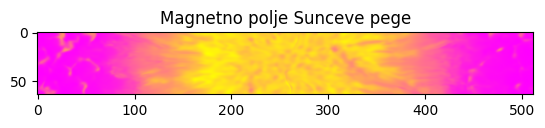

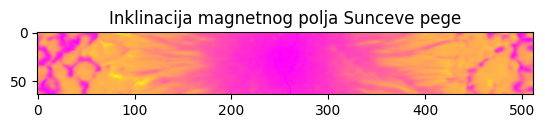

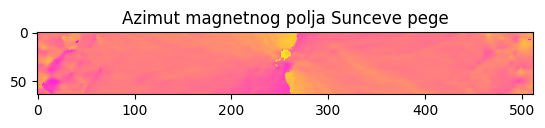

In [26]:
naslov=['Magnetno polje Sunceve pege', 'Inklinacija magnetnog polja Sunceve pege', 'Azimut magnetnog polja Sunceve pege']

for p,naslov in zip(podaci,naslov):
    plt.figure()
    plt.imshow(p,cmap='spring')
    plt.title(naslov)
    plt.show()

mean B: 1795.597 std B 1163.6923 median B 2043.2295 sigma G B 2407.120315551758 asimetricnost B -0.2409446342224698 kurtosis B -1.5021304679404892


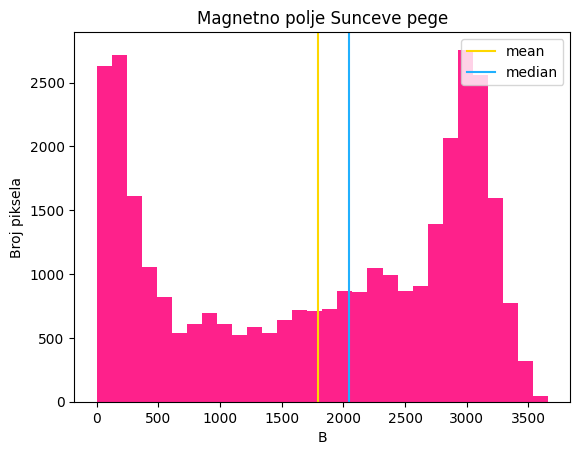

In [8]:
x__B=np.mean(B)
s_B=np.std(B, ddof=1)
medijana_B=np.median(B)
q25B=np.percentile(B,25)
q75B=np.percentile(B,75)
sigma_GB=q75B-q25B
sk_B=skew(B)
ku_B=kurtosis(B)

print('mean B:',x__B,'std B',s_B,'median B',medijana_B,'sigma G B',sigma_GB,'asimetricnost B',sk_B,'kurtosis B',ku_B)

plt.figure()
plt.hist(B, bins=30,color='#fe218b')
plt.axvline(x__B,color='#fed700',label='mean')
plt.axvline(medijana_B,color='#21b0fe',label='median')
plt.title('Magnetno polje Sunceve pege')
plt.xlabel('B')
plt.ylabel('Broj piksela')
plt.legend()
plt.show()

mean theta: 55.362022 std theta 26.305918 median theta 59.85235 sigma G theta 47.69920587539673 asimetricnost theta -0.3372983040508299 kurtosis theta -1.1760242490410715


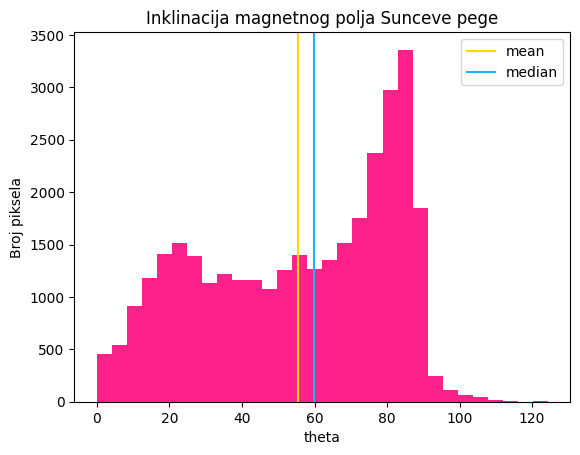

In [9]:
x__t=np.mean(theta)
s_t=np.std(theta, ddof=1)
medijana_t=np.median(theta)
q25t=np.percentile(theta,25)
q75t=np.percentile(theta,75)
sigma_Gt=q75t-q25t
sk_t=skew(theta)
ku_t=kurtosis(theta)

print('mean theta:',x__t,'std theta',s_t,'median theta',medijana_t,'sigma G theta',sigma_Gt,'asimetricnost theta',sk_t,'kurtosis theta',ku_t)

plt.figure()
plt.hist(theta, bins=30,color='#fe218b')
plt.axvline(x__t,color='#fed700',label='mean')
plt.axvline(medijana_t,color='#21b0fe',label='median')
plt.title('Inklinacija magnetnog polja Sunceve pege')
plt.xlabel('theta')
plt.ylabel('Broj piksela')
plt.legend()
plt.show()

mean phi: -0.56873405 std phi 26.818502 median phi -1.429375 sigma G phi 21.104724168777466 asimetricnost phi 0.44274793009951824 kurtosis phi 5.735422302515328


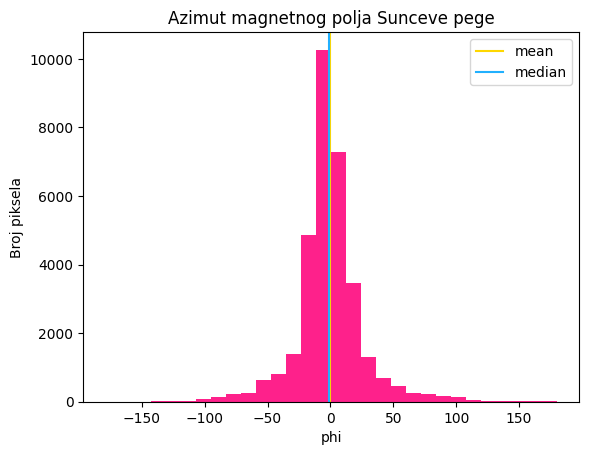

In [10]:
x__p=np.mean(phi)
s_p=np.std(phi, ddof=1)
medijana_p=np.median(phi)
q25p=np.percentile(phi,25)
q75p=np.percentile(phi,75)
sigma_Gp=q75p-q25p
sk_p=skew(phi)
ku_p=kurtosis(phi)

print('mean phi:',x__p,'std phi',s_p,'median phi',medijana_p,'sigma G phi',sigma_Gp,'asimetricnost phi',sk_p,'kurtosis phi',ku_p)

plt.figure()
plt.hist(phi, bins=30,color='#fe218b')
plt.axvline(x__p,color='#fed700',label='mean')
plt.axvline(medijana_p,color='#21b0fe',label='median')
plt.title('Azimut magnetnog polja Sunceve pege')
plt.xlabel('phi')
plt.ylabel('Broj piksela')
plt.legend()
plt.show()

Mean i standardna devijacija nisu robusne jer su osetljive na ekstremne vrednosti.  
Median i σG su robusne statistike jer zavise od sredisnjeg dela raspodele.

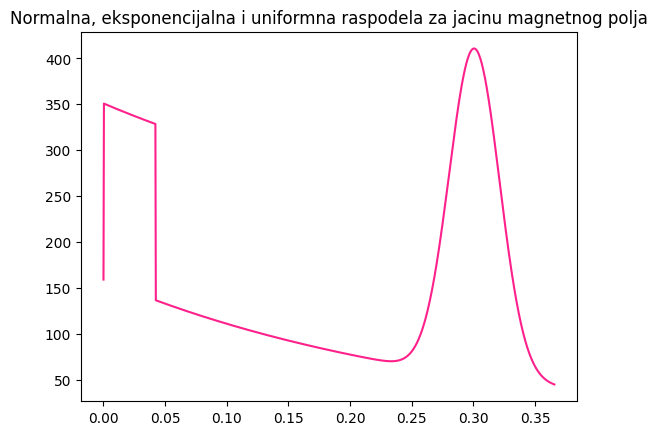

In [23]:
B_flat=B

def raspodela(xB,
              aB,muB,sigmaB,
              bB,lambB,
              cB,pocetak,kraj):
    normalna=aB*norm.pdf(xB,loc=muB, scale=sigmaB)
    eksponencijalna=bB*expon.pdf(xB, scale=1/lambB)
    uniformna=cB*uniform.pdf(xB,loc=pocetak, scale=kraj-pocetak)
    return normalna+eksponencijalna+uniformna
    
p0=[0.3,np.mean(B_flat),np.std(B_flat),
    0.3,1,
    0.3,B_flat.min(),B_flat.max()]

x_data =np.linspace(B_flat.min(), B_flat.max(), 200)
y_data,_= np.histogram(B_flat, bins=200)
params, _ = curve_fit(raspodela, x_data, y_data, p0=p0)


x = np.linspace(B_flat.min(), B_flat.max(), 1000)
y = raspodela(x, *params)

plt.figure()
plt.plot(x, y,color='#fe218b')
plt.title('Normalna, eksponencijalna i uniformna raspodela za jacinu magnetnog polja')
plt.show()

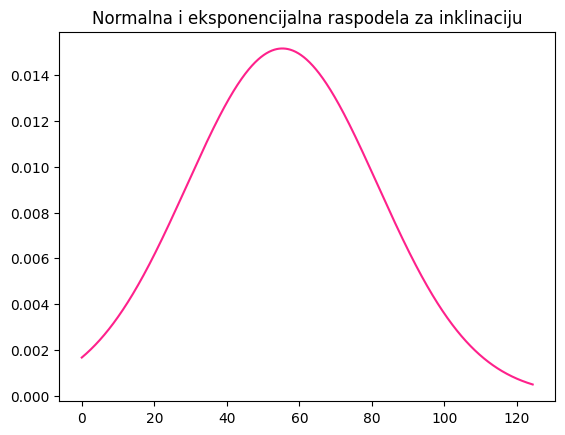

In [24]:
theta_flat=theta
K,mu_theta,sigma=exponnorm.fit(theta_flat)
x_theta=np.linspace(theta_flat.min(),theta_flat.max(),1000)
pdf_theta=exponnorm.pdf(x_theta,K,loc=mu_theta,scale=sigma)
plt.figure()
plt.plot(x_theta,pdf_theta,color='#fe218b')
plt.title('Normalna i eksponencijalna raspodela za inklinaciju')
plt.show()

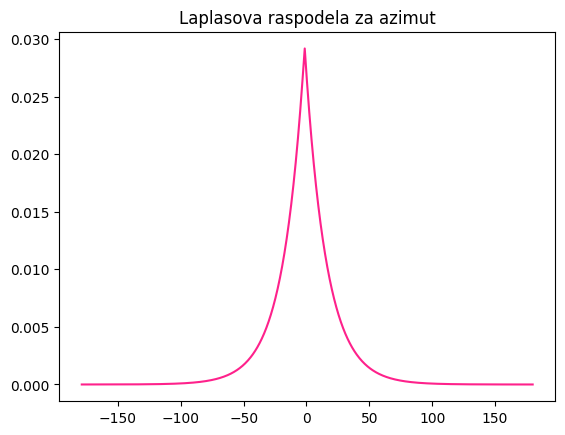

In [25]:
phi_flat=phi
mu,b=laplace.fit(phi_flat)
x=np.linspace(phi_flat.min(),phi_flat.max(),1000)
pdf=laplace.pdf(x,loc=mu,scale=b)
plt.figure()
plt.plot(x,pdf,color='#fe218b')
plt.title('Laplasova raspodela za azimut')
plt.show()

Centralna granicna teorema

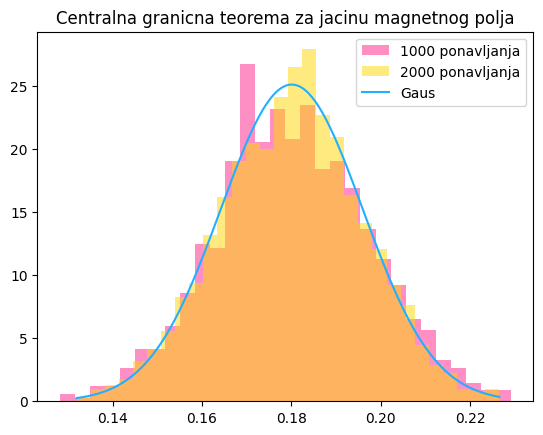

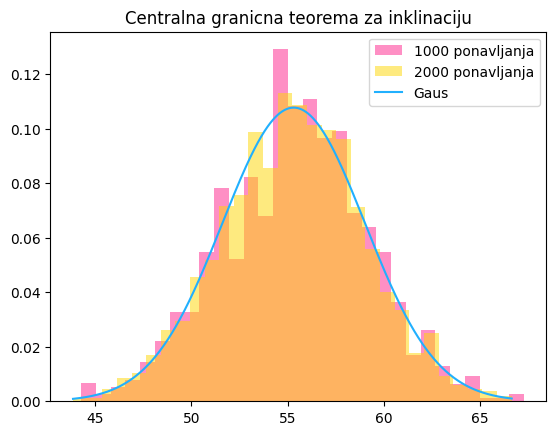

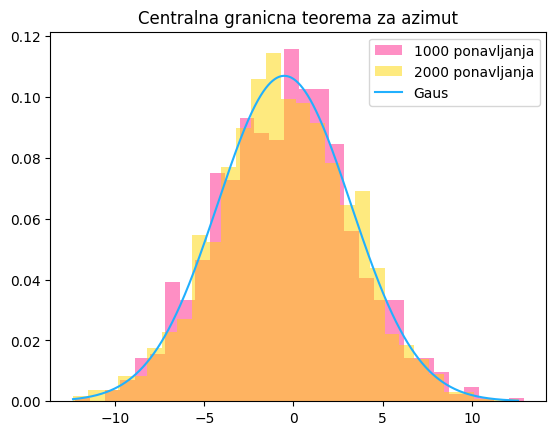

In [16]:
n_samples1=1000
n_samples2=2000
sample_size=50

meanB1=[]
meant1=[]
meanp1=[]


meanB2=[]
meant2=[]
meanp2=[]

for i in range (n_samples1):
    sampleB1=np.random.choice(B,size=sample_size, replace=True)
    meanB1.append(np.mean(sampleB1))
    samplet1=np.random.choice(theta,size=sample_size, replace=True)
    meant1.append(np.mean(samplet1))
    samplep1=np.random.choice(phi,size=sample_size, replace=True)
    meanp1.append(np.mean(samplep1))
    
meanB1 = np.array(meanB1)
meant1 = np.array(meant1)
meanp1 = np.array(meanp1)




for i in range (n_samples2):
    sampleB2=np.random.choice(B,size=sample_size, replace=True)
    meanB2.append(np.mean(sampleB2))
    samplet2=np.random.choice(theta,size=sample_size, replace=True)
    meant2.append(np.mean(samplet2))
    samplep2=np.random.choice(phi,size=sample_size, replace=True)
    meanp2.append(np.mean(samplep2))
    
meanB2 = np.array(meanB2)
meant2 = np.array(meant2)
meanp2 = np.array(meanp2)





muB = np.mean(meanB2)
sigmaB = np.std(meanB2)
xB = np.linspace(min(meanB2), max(meanB2), 1000)
pdfB = norm.pdf(xB, loc=muB, scale=sigmaB)

mut = np.mean(meant2)
sigmat = np.std(meant2)
xt = np.linspace(min(meant2), max(meant2), 1000)
pdft = norm.pdf(xt, loc=mut, scale=sigmat)

mup = np.mean(meanp2)
sigmap = np.std(meanp2)
xp = np.linspace(min(meanp2), max(meanp2), 1000)
pdfp = norm.pdf(xp, loc=mup, scale=sigmap)


plt.figure()
plt.hist(meanB1, bins=30, density=True, color='#fe218b',alpha=0.5, label='1000 ponavljanja')
plt.hist(meanB2, bins=30, density=True, color='#fed700',alpha=0.5, label='2000 ponavljanja')
plt.plot(xB, pdfB, color='#21b0fe', label='Gaus')
plt.title("Centralna granicna teorema za jacinu magnetnog polja")
plt.legend()
plt.show()

plt.figure()
plt.hist(meant1, bins=30, density=True, color='#fe218b',alpha=0.5, label='1000 ponavljanja')
plt.hist(meant2, bins=30, density=True, color='#fed700',alpha=0.5, label='2000 ponavljanja')
plt.plot(xt, pdft, color='#21b0fe', label='Gaus')
plt.title("Centralna granicna teorema za inklinaciju")
plt.legend()
plt.show()

plt.figure()
plt.hist(meanp1, bins=30, density=True, color='#fe218b',alpha=0.5,label='1000 ponavljanja')
plt.hist(meanp2, bins=30, density=True, color='#fed700',alpha=0.5, label='2000 ponavljanja')
plt.plot(xp, pdfp, color='#21b0fe', label='Gaus')
plt.title("Centralna granicna teorema za azimut")
plt.legend()
plt.show()

Distribucija srednjih vrednosti uzoraka teži normalnoj raspodeli kako raste broj uzoraka

Magnetni pritisak

In [15]:
B=B/10**4
mu0=4*np.pi*10**(-7)

P=B**2/(2*mu0)

sB=np.std(B)
dPdB=np.mean(B)/mu0

sP=sB*dPdB

sigmaP=np.std(P)

razlika=np.abs(sP-sigmaP)
print('Odstupanje sP od greske izracunate direktno iz P ',razlika)

Odstupanje sP od greske izracunate direktno iz P  887.2543684949087
